# F1 Pit Stop Prediction — Data Preprocessing & EDA

**Project:** Modeling Pit Stop Strategy in Formula 1  
**Team ORIE:** He Sun, Yilin Wang, Weifan Wu, Peter Ye  
**Course:** INFO 5368-030 PAML

---

This notebook performs:
1. Data loading & inspection
2. Data quality checks
3. Missing value handling
4. Data leakage removal
5. Outlier treatment
6. Feature engineering
7. Categorical encoding (one-hot)
8. Feature standardization
9. Time-based train/test split
10. Save processed dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

print('Libraries loaded.')

Libraries loaded.


## 1. Load Raw Data

In [2]:
raw_df = pd.read_csv('Dataset/f1_strategy_dataset_v4.csv')
print(f'Dataset shape: {raw_df.shape}')
print(f'Columns: {list(raw_df.columns)}')
raw_df.head(10)

Dataset shape: (101371, 16)
Columns: ['Driver', 'LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'Race', 'Year', 'LapTime_Delta', 'Cumulative_Degradation', 'PitStop', 'PitNextLap', 'RaceProgress', 'Normalized_TyreLife', 'Position_Change']


,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0
5,ALB,6,MEDIUM,1,7.0,18,91.491,Abu Dhabi Grand Prix,2023,0.069,-9.134,0,0,0.103448,0.411765,0.0
6,ALB,7,MEDIUM,1,8.0,18,91.438,Abu Dhabi Grand Prix,2023,-0.053,-9.187,0,0,0.120690,0.470588,0.0
7,ALB,8,MEDIUM,1,9.0,17,91.580,Abu Dhabi Grand Prix,2023,0.142,-9.045,0,0,0.137931,0.529412,1.0
8,ALB,9,MEDIUM,1,10.0,17,91.644,Abu Dhabi Grand Prix,2023,0.064,-8.981,0,0,0.155172,0.588235,0.0
9,ALB,10,MEDIUM,1,11.0,17,91.978,Abu Dhabi Grand Prix,2023,0.334,-8.647,0,0,0.172414,0.647059,0.0


In [3]:
raw_df.dtypes

Driver                     object
LapNumber                   int64
Compound                   object
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
Race                       object
Year                        int64
LapTime_Delta             float64
Cumulative_Degradation    float64
PitStop                     int64
PitNextLap                  int64
RaceProgress              float64
Normalized_TyreLife       float64
Position_Change           float64
dtype: object

In [4]:
raw_df.describe()

,LapNumber,Stint,TyreLife,Position,LapTime (s),Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
count,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000
mean,30.444841,2.046394,14.549339,9.759132,92.587188,2023.589685,-0.203891,-29.550051,0.251581,0.254797,0.432618,0.386521,-0.004636
std,18.146942,0.948797,10.313385,5.406456,33.231414,1.098518,45.344910,70.235759,0.433924,0.435749,0.258129,0.259906,3.912725
min,1.000000,1.000000,1.000000,1.000000,67.012000,2022.000000,-2403.895000,-274.564000,0.000000,0.000000,0.012821,0.012821,-18.000000
25%,15.000000,1.000000,7.000000,5.000000,82.021000,2023.000000,-7.253000,-51.054500,0.000000,0.000000,0.210526,0.172414,-2.000000
50%,30.000000,2.000000,13.000000,10.000000,91.167000,2024.000000,-0.027000,-21.678000,0.000000,0.000000,0.421053,0.333333,0.000000
75%,45.000000,3.000000,20.000000,14.000000,99.356000,2025.000000,5.705000,-3.725500,1.000000,1.000000,0.631579,0.562500,2.000000
max,78.000000,8.000000,78.000000,20.000000,2526.253000,2025.000000,2433.472000,2412.431000,1.000000,1.000000,1.000000,1.000000,18.000000


## 2. Data Quality Checks

### 2.1 Missing Values

In [5]:
missing = raw_df.isnull().sum()
missing_pct = (missing / len(raw_df) * 100).round(3)
missing_summary = pd.DataFrame({'count': missing, 'pct(%)': missing_pct})
print(missing_summary[missing_summary['count'] > 0])
print(f'\nOnly "Compound" has {missing["Compound"]} missing values ({missing_pct["Compound"]:.3f}%)')

          count  pct(%)
Compound     66   0.065

Only "Compound" has 66 missing values (0.065%)


In [6]:
# Inspect the missing Compound rows
print('Rows with missing Compound:')
raw_df[raw_df['Compound'].isna()][['Driver','Race','Year','LapNumber','Stint','TyreLife','Compound']].head(10)

Rows with missing Compound:


,Driver,Race,Year,LapNumber,Stint,TyreLife,Compound
81155,RUS,Austrian Grand Prix,2022,41,3,4.0,NaN
81156,RUS,Austrian Grand Prix,2022,42,3,5.0,NaN
81157,RUS,Austrian Grand Prix,2022,43,3,6.0,NaN
81158,RUS,Austrian Grand Prix,2022,44,3,7.0,NaN
81159,RUS,Austrian Grand Prix,2022,45,3,8.0,NaN
81160,RUS,Austrian Grand Prix,2022,46,3,9.0,NaN
81161,RUS,Austrian Grand Prix,2022,47,3,10.0,NaN
81162,RUS,Austrian Grand Prix,2022,48,3,11.0,NaN
81163,RUS,Austrian Grand Prix,2022,49,3,12.0,NaN
81164,RUS,Austrian Grand Prix,2022,50,3,13.0,NaN


### 2.2 Target Distribution by Year

**Critical finding:** 2023 has an anomalously low pit rate (~3%) compared to other years (~32%). This suggests a data labeling issue for the 2023 season. We flag this and exclude 2023 from our dataset to avoid introducing noise.

      pit_count  total_laps  pit_rate
Year                                 
2022       6984       21860  0.319488
2023        768       24914  0.030826
2024       9244       27557  0.335450
2025       8833       27040  0.326664


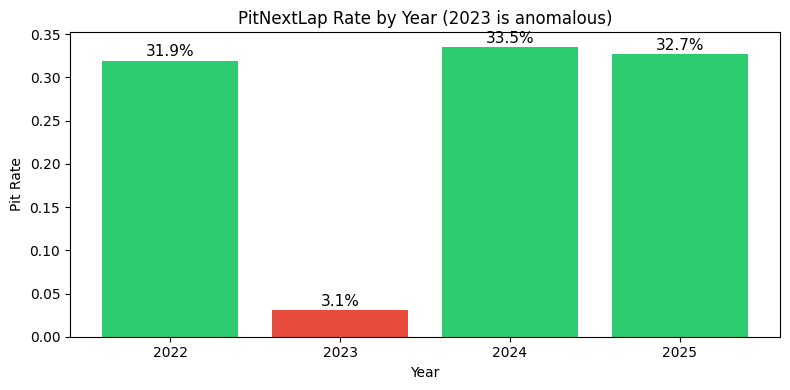

In [7]:
pit_rate_by_year = raw_df.groupby('Year')['PitNextLap'].agg(['sum','count','mean'])
pit_rate_by_year.columns = ['pit_count', 'total_laps', 'pit_rate']
print(pit_rate_by_year)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(pit_rate_by_year.index.astype(str), pit_rate_by_year['pit_rate'], 
              color=['#2ecc71','#e74c3c','#2ecc71','#2ecc71'])
ax.set_ylabel('Pit Rate')
ax.set_xlabel('Year')
ax.set_title('PitNextLap Rate by Year (2023 is anomalous)')
for bar, rate in zip(bars, pit_rate_by_year['pit_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
            f'{rate:.1%}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

### 2.3 Outlier Detection — LapTime_Delta

LapTime_Delta percentiles:
    1.0%:    -44.437
    5.0%:    -26.124
   25.0%:     -7.253
   50.0%:     -0.027
   75.0%:      5.705
   95.0%:     27.519
   99.0%:     44.838
  Min:    -2403.895
  Max:     2433.472


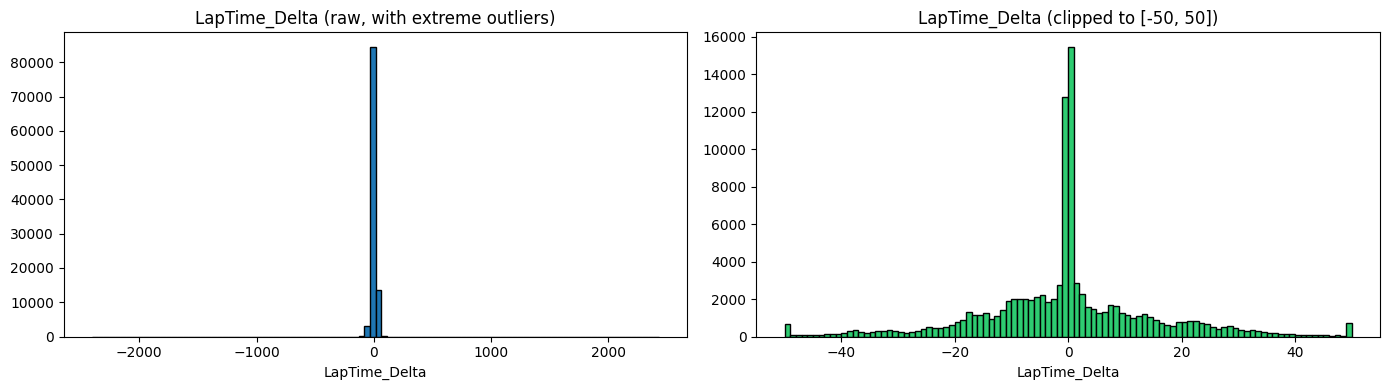

In [8]:
print('LapTime_Delta percentiles:')
for p in [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]:
    print(f'  {p*100:5.1f}%: {raw_df["LapTime_Delta"].quantile(p):>10.3f}')
print(f'  Min:   {raw_df["LapTime_Delta"].min():>10.3f}')
print(f'  Max:   {raw_df["LapTime_Delta"].max():>10.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(raw_df['LapTime_Delta'], bins=100, edgecolor='black')
axes[0].set_title('LapTime_Delta (raw, with extreme outliers)')
axes[0].set_xlabel('LapTime_Delta')

clipped = raw_df['LapTime_Delta'].clip(-50, 50)
axes[1].hist(clipped, bins=100, edgecolor='black', color='#2ecc71')
axes[1].set_title('LapTime_Delta (clipped to [-50, 50])')
axes[1].set_xlabel('LapTime_Delta')
plt.tight_layout()
plt.show()

### 2.4 Class Distribution (overall)

/var/folders/5p/s7bsktj14j10w1mv8lr4387c0000gn/T/ipykernel_7726/4043068804.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([pit0, pit1], labels=['No Pit', 'Pit'])


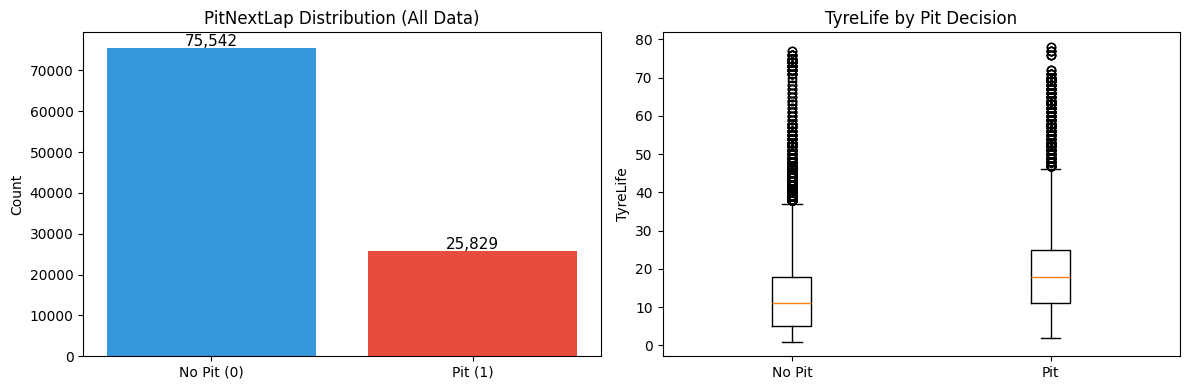

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = raw_df['PitNextLap'].value_counts().sort_index()
axes[0].bar(['No Pit (0)', 'Pit (1)'], counts.values, color=['#3498db','#e74c3c'])
axes[0].set_title('PitNextLap Distribution (All Data)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=11)

# Boxplot of TyreLife by PitNextLap
pit0 = raw_df[raw_df['PitNextLap']==0]['TyreLife']
pit1 = raw_df[raw_df['PitNextLap']==1]['TyreLife']
axes[1].boxplot([pit0, pit1], labels=['No Pit', 'Pit'])
axes[1].set_title('TyreLife by Pit Decision')
axes[1].set_ylabel('TyreLife')

plt.tight_layout()
plt.show()

### 2.5 Compound Distribution

Compound
HARD            44967
MEDIUM          37639
SOFT            12744
INTERMEDIATE     5556
WET               399
Name: count, dtype: int64


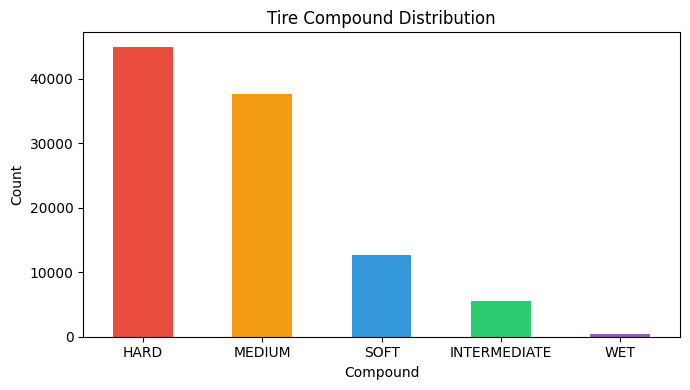

In [10]:
compound_counts = raw_df['Compound'].value_counts()
print(compound_counts)

fig, ax = plt.subplots(figsize=(7, 4))
compound_counts.plot(kind='bar', ax=ax, color=['#e74c3c','#f39c12','#3498db','#2ecc71','#9b59b6'])
ax.set_title('Tire Compound Distribution')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 2.6 Correlation Heatmap

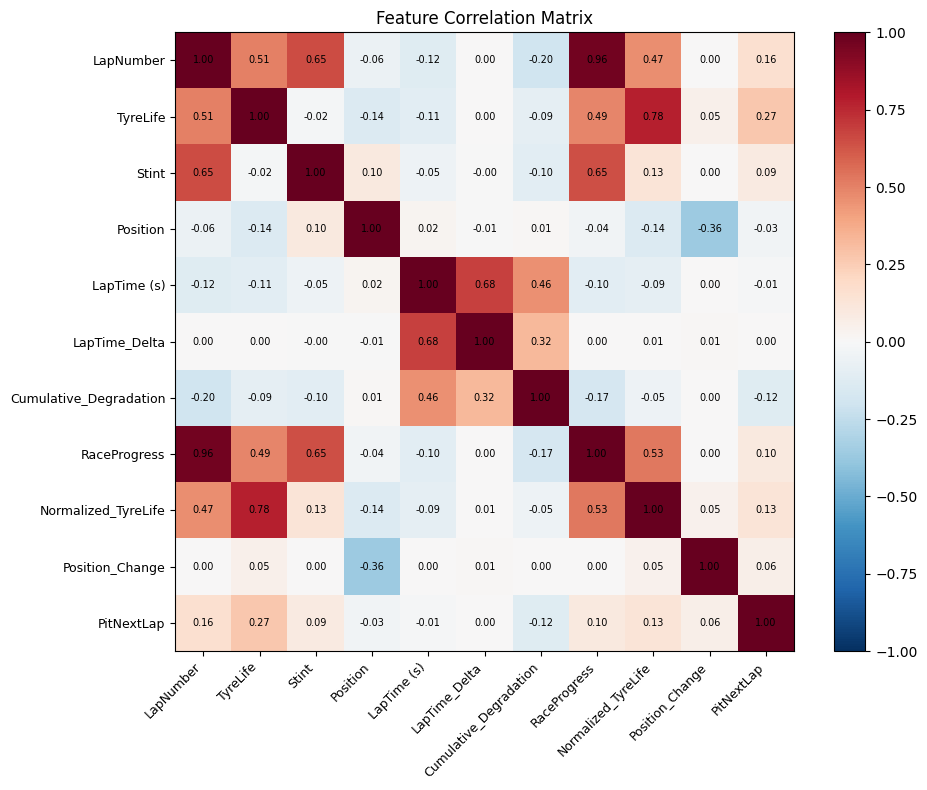


Correlation with PitNextLap (sorted by absolute value):
  TyreLife                      : +0.2662
  LapNumber                     : +0.1596
  Normalized_TyreLife           : +0.1254
  Cumulative_Degradation        : -0.1223
  RaceProgress                  : +0.0992
  Stint                         : +0.0870
  Position_Change               : +0.0575
  Position                      : -0.0322
  LapTime (s)                   : -0.0101
  LapTime_Delta                 : +0.0036


In [11]:
numeric_cols = ['LapNumber', 'TyreLife', 'Stint', 'Position', 'LapTime (s)',
                'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress',
                'Normalized_TyreLife', 'Position_Change', 'PitNextLap']
corr = raw_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)

# Add correlation values
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7)

plt.colorbar(im)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Print features most correlated with PitNextLap
print('\nCorrelation with PitNextLap (sorted by absolute value):')
target_corr = corr['PitNextLap'].drop('PitNextLap').abs().sort_values(ascending=False)
for feat, val in target_corr.items():
    direction = corr.loc[feat, 'PitNextLap']
    print(f'  {feat:30s}: {direction:+.4f}')

---
## 3. Data Cleaning & Preprocessing

Steps:
1. **Drop 2023** — anomalous pit rate (3% vs 32%)
2. **Drop `PitStop` column** — data leakage (PitStop[t] ≈ PitNextLap[t-1])
3. **Drop `Normalized_TyreLife`** — redundant with `TyreLife` (r=0.88), no new information
4. **Drop rows with missing `Compound`** — only 66 rows (0.065% of raw data), data collection gaps
5. **Clip `LapTime (s)`** — to 1st–99th percentile (**train-year quantiles only** to avoid leakage)
6. **Clip `LapTime_Delta`** — same treatment (train-year quantiles)
7. **Clip `Cumulative_Degradation`** — same treatment (train-year quantiles)

In [12]:
df = raw_df.copy()
print(f'Starting shape: {df.shape}')

# 3.1 Drop 2023 season (anomalous pit labeling)
df = df[df['Year'] != 2023].copy()
print(f'After dropping 2023: {df.shape}')

# 3.2 Drop PitStop column (data leakage)
df = df.drop(columns=['PitStop'])
print(f'After dropping PitStop: {df.shape}')

# 3.3 Drop Normalized_TyreLife (redundant with TyreLife, r=0.88 — no new information)
df = df.drop(columns=['Normalized_TyreLife'])
print(f'After dropping Normalized_TyreLife: {df.shape}')

# 3.4 Drop rows with missing Compound (only 66 rows, all from 2022 Austrian GP)
n_missing = df['Compound'].isna().sum()
df = df.dropna(subset=['Compound'])
print(f'Dropped {n_missing} rows with missing Compound ({n_missing/len(raw_df)*100:.3f}% of raw data)')

# 3.5–3.7 Clip outliers using TRAIN-YEAR quantiles only (avoid data leakage)
# Compute 1st/99th percentiles from train years (2022+2024) only
train_mask = df['Year'].isin([2022, 2024])
print(f'\nClip boundaries computed from train years only ({train_mask.sum():,} rows):')

for col_name in ['LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation']:
    lo = df.loc[train_mask, col_name].quantile(0.01)
    hi = df.loc[train_mask, col_name].quantile(0.99)
    print(f'  Clipping {col_name} to [{lo:.2f}, {hi:.2f}]')
    df[col_name] = df[col_name].clip(lo, hi)  # Apply to ALL rows (train+test)

# Verify
print(f'\nCleaned shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'PitNextLap rate: {df["PitNextLap"].mean():.2%}')
print(f'Compound values: {sorted(df["Compound"].unique())}')

Starting shape: (101371, 16)
After dropping 2023: (76457, 16)
After dropping PitStop: (76457, 15)
After dropping Normalized_TyreLife: (76457, 14)
Dropped 66 rows with missing Compound (0.065% of raw data)

Clip boundaries computed from train years only (49,351 rows):
  Clipping LapTime (s) to [70.58, 141.80]
  Clipping LapTime_Delta to [-48.47, 49.85]
  Clipping Cumulative_Degradation to [-139.82, 81.34]

Cleaned shape: (76391, 14)
Missing values: 0
PitNextLap rate: 32.76%
Compound values: ['HARD', 'INTERMEDIATE', 'MEDIUM', 'SOFT', 'WET']


## 4. Feature Engineering

Clipping Degradation_Rate to [-15.3690, 24.9260] (train-year quantiles)



New feature: Degradation_Rate (after clipping)
count    76391.000000
mean         0.216180
std          4.380554
min        -15.369000
25%         -0.798446
50%         -0.011444
75%          0.703683
max         24.926000
Name: Degradation_Rate, dtype: float64


/var/folders/5p/s7bsktj14j10w1mv8lr4387c0000gn/T/ipykernel_7726/471047452.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([dr_0, dr_1], labels=['No Pit', 'Pit'])


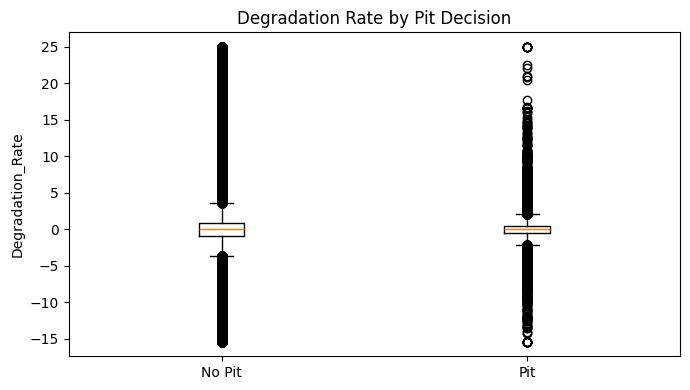

In [13]:
# 4.1 Degradation Rate = LapTime_Delta / TyreLife
#     Measures per-lap tire degradation efficiency.
#     Higher value → tire is degrading faster per lap → more likely to pit
df['Degradation_Rate'] = df['LapTime_Delta'] / df['TyreLife'].replace(0, 1)

# Clip Degradation_Rate using train-year quantiles only (same leakage-safe approach)
train_mask = df['Year'].isin([2022, 2024])
dr_lo = df.loc[train_mask, 'Degradation_Rate'].quantile(0.01)
dr_hi = df.loc[train_mask, 'Degradation_Rate'].quantile(0.99)
print(f'Clipping Degradation_Rate to [{dr_lo:.4f}, {dr_hi:.4f}] (train-year quantiles)')
df['Degradation_Rate'] = df['Degradation_Rate'].clip(dr_lo, dr_hi)

print('\nNew feature: Degradation_Rate (after clipping)')
print(df['Degradation_Rate'].describe())

# Visualize: Degradation_Rate by PitNextLap
fig, ax = plt.subplots(figsize=(7, 4))
dr_0 = df[df['PitNextLap']==0]['Degradation_Rate']
dr_1 = df[df['PitNextLap']==1]['Degradation_Rate']
ax.boxplot([dr_0, dr_1], labels=['No Pit', 'Pit'])
ax.set_title('Degradation Rate by Pit Decision')
ax.set_ylabel('Degradation_Rate')
plt.tight_layout()
plt.show()

## 5. Categorical Encoding

In [14]:
# 5.1 One-Hot Encode: Compound (SOFT, MEDIUM, HARD, INTERMEDIATE, WET)
print(f'Compound values: {sorted(df["Compound"].unique())}')
compound_dummies = pd.get_dummies(df['Compound'], prefix='Compound')
print(f'One-hot columns created: {list(compound_dummies.columns)}')

df = pd.concat([df, compound_dummies], axis=1)

# 5.2 Label Encode: Driver (too many categories for one-hot)
driver_map = {d: i for i, d in enumerate(sorted(df['Driver'].unique()))}
df['Driver_encoded'] = df['Driver'].map(driver_map)
print(f'\nDriver encoded: {len(driver_map)} drivers → integers 0-{len(driver_map)-1}')

# 5.3 Drop original categorical columns (and Race — info captured by other features)
df = df.drop(columns=['Driver', 'Compound', 'Race'])
print(f'\nAfter encoding, shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

Compound values: ['HARD', 'INTERMEDIATE', 'MEDIUM', 'SOFT', 'WET']
One-hot columns created: ['Compound_HARD', 'Compound_INTERMEDIATE', 'Compound_MEDIUM', 'Compound_SOFT', 'Compound_WET']

Driver encoded: 31 drivers → integers 0-30

After encoding, shape: (76391, 18)
Columns: ['LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'Year', 'LapTime_Delta', 'Cumulative_Degradation', 'PitNextLap', 'RaceProgress', 'Position_Change', 'Degradation_Rate', 'Compound_HARD', 'Compound_INTERMEDIATE', 'Compound_MEDIUM', 'Compound_SOFT', 'Compound_WET', 'Driver_encoded']


## 6. Define Feature Sets & Target

In [15]:
# Define target
target_col = 'PitNextLap'

# Define feature columns (exclude target, Year is kept for splitting, then dropped)
exclude_cols = [target_col, 'Year']
feature_cols = [c for c in df.columns if c not in exclude_cols]

print(f'Target: {target_col}')
print(f'Number of features: {len(feature_cols)}')
print(f'Feature columns:')
for i, c in enumerate(feature_cols, 1):
    print(f'  {i:2d}. {c}')

Target: PitNextLap
Number of features: 16
Feature columns:
   1. LapNumber
   2. Stint
   3. TyreLife
   4. Position
   5. LapTime (s)
   6. LapTime_Delta
   7. Cumulative_Degradation
   8. RaceProgress
   9. Position_Change
  10. Degradation_Rate
  11. Compound_HARD
  12. Compound_INTERMEDIATE
  13. Compound_MEDIUM
  14. Compound_SOFT
  15. Compound_WET
  16. Driver_encoded


## 7. Time-Based Train / Test Split

We use a **temporal split** to avoid data leakage from sequential race data:
- **Train:** 2022 + 2024 (~65%)
- **Test:** 2025 (~35%)

Note: 2023 was already excluded due to anomalous labeling.

For **Time-Series Cross Validation** (used during hyperparameter tuning):
- Fold 1: Train=2022, Val=2024
- Fold 2: Train=2022+2024, Val=2025 (final evaluation)

In [16]:
# Split by year
train_df = df[df['Year'].isin([2022, 2024])].copy()
test_df  = df[df['Year'] == 2025].copy()

print(f'Train: {len(train_df):,} rows ({len(train_df)/len(df):.1%}) — Years: {sorted(train_df["Year"].unique())}')
print(f'Test:  {len(test_df):,} rows ({len(test_df)/len(df):.1%}) — Years: {sorted(test_df["Year"].unique())}')
print(f'Total: {len(df):,}')
print(f'\nTrain pit rate: {train_df[target_col].mean():.2%}')
print(f'Test  pit rate: {test_df[target_col].mean():.2%}')

Train: 49,351 rows (64.6%) — Years: [np.int64(2022), np.int64(2024)]
Test:  27,040 rows (35.4%) — Years: [np.int64(2025)]
Total: 76,391

Train pit rate: 32.81%
Test  pit rate: 32.67%


## 8. Feature Standardization

Standardize numeric features using **train set statistics** (mean, std).  
Binary/one-hot columns are left unchanged.

In [17]:
# Identify numeric features to standardize
# Exclude:
#   - binary/one-hot columns (Compound_*) — already in [0,1], no scaling needed
#   - Driver_encoded — label encoding (categorical, not ordinal numeric); scaling distorts meaning
binary_cols = [c for c in feature_cols if c.startswith('Compound_')]
categorical_cols = ['Driver_encoded']
numeric_features_to_scale = [c for c in feature_cols if c not in binary_cols and c not in categorical_cols]

print(f'Features to standardize ({len(numeric_features_to_scale)}):')
for c in numeric_features_to_scale:
    print(f'  {c}')
print(f'\nCategorical features kept as-is ({len(categorical_cols)}):')
for c in categorical_cols:
    print(f'  {c}  ← label encoded, not standardized')
print(f'\nBinary features kept as-is ({len(binary_cols)}):')
for c in binary_cols:
    print(f'  {c}')

Features to standardize (10):
  LapNumber
  Stint
  TyreLife
  Position
  LapTime (s)
  LapTime_Delta
  Cumulative_Degradation
  RaceProgress
  Position_Change
  Degradation_Rate

Categorical features kept as-is (1):
  Driver_encoded  ← label encoded, not standardized

Binary features kept as-is (5):
  Compound_HARD
  Compound_INTERMEDIATE
  Compound_MEDIUM
  Compound_SOFT
  Compound_WET


In [18]:
# Convert integer columns to float before standardization (avoids dtype warnings)
for col in numeric_features_to_scale:
    train_df[col] = train_df[col].astype(float)
    test_df[col]  = test_df[col].astype(float)

# Compute mean and std from TRAIN set only (avoid data leakage)
train_mean = train_df[numeric_features_to_scale].mean()
train_std  = train_df[numeric_features_to_scale].std()
train_std   = train_std.replace(0, 1)  # avoid division by zero

# Apply standardization
train_df.loc[:, numeric_features_to_scale] = (train_df[numeric_features_to_scale] - train_mean) / train_std
test_df.loc[:, numeric_features_to_scale]  = (test_df[numeric_features_to_scale]  - train_mean) / train_std

print('Standardization applied (train stats → both sets).')
print('\nTrain set stats after standardization:')
print(train_df[numeric_features_to_scale].describe().loc[['mean','std']].round(4))

Standardization applied (train stats → both sets).

Train set stats after standardization:
      LapNumber  Stint  TyreLife  Position  LapTime (s)  LapTime_Delta  Cumulative_Degradation  RaceProgress  Position_Change  Degradation_Rate
mean        0.0    0.0      -0.0       0.0          0.0           -0.0                    -0.0          -0.0             -0.0              -0.0
std         1.0    1.0       1.0       1.0          1.0            1.0                     1.0           1.0              1.0               1.0


## 9. Final Check & Summary

In [19]:
# Prepare final X and y
X_train = train_df[feature_cols].values
y_train = train_df[target_col].values

X_test = test_df[feature_cols].values
y_test = test_df[target_col].values

print('========== FINAL DATASET SUMMARY ==========')
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape} | pit rate: {y_train.mean():.2%}')
print(f'X_test:  {X_test.shape}')
print(f'y_test:  {y_test.shape} | pit rate: {y_test.mean():.2%}')
print(f'\nFeature columns ({len(feature_cols)}):')
for i, c in enumerate(feature_cols, 1):
    print(f'  {i:2d}. {c}')
print(f'\nNo missing values: {train_df[feature_cols].isnull().sum().sum() == 0}')
print(f'No missing values (test): {test_df[feature_cols].isnull().sum().sum() == 0}')

========== FINAL DATASET SUMMARY ==========
X_train: (49351, 16)
y_train: (49351,) | pit rate: 32.81%
X_test:  (27040, 16)
y_test:  (27040,) | pit rate: 32.67%

Feature columns (16):
   1. LapNumber
   2. Stint
   3. TyreLife
   4. Position
   5. LapTime (s)
   6. LapTime_Delta
   7. Cumulative_Degradation
   8. RaceProgress
   9. Position_Change
  10. Degradation_Rate
  11. Compound_HARD
  12. Compound_INTERMEDIATE
  13. Compound_MEDIUM
  14. Compound_SOFT
  15. Compound_WET
  16. Driver_encoded

No missing values: True
No missing values (test): True


## 10. Save Processed Data

In [20]:
# Save processed train and test sets
output_dir = 'Dataset'

# Save with all columns (features + target + Year for reference)
train_save = train_df[feature_cols + [target_col, 'Year']]
test_save  = test_df[feature_cols + [target_col, 'Year']]

train_path = os.path.join(output_dir, 'f1_train_processed.csv')
test_path  = os.path.join(output_dir, 'f1_test_processed.csv')

train_save.to_csv(train_path, index=False)
test_save.to_csv(test_path, index=False)

print(f'Saved: {train_path} ({len(train_save):,} rows)')
print(f'Saved: {test_path} ({len(test_save):,} rows)')

# Also save the standardization parameters for Streamlit app
scaler_params = pd.DataFrame({'mean': train_mean, 'std': train_std})
scaler_path = os.path.join(output_dir, 'scaler_params.csv')
scaler_params.to_csv(scaler_path)
print(f'Saved: {scaler_path} (for Streamlit inference)')

# Save driver mapping
driver_map_df = pd.DataFrame(list(driver_map.items()), columns=['Driver', 'Encoded'])
driver_map_path = os.path.join(output_dir, 'driver_mapping.csv')
driver_map_df.to_csv(driver_map_path, index=False)
print(f'Saved: {driver_map_path}')

Saved: Dataset/f1_train_processed.csv (49,351 rows)
Saved: Dataset/f1_test_processed.csv (27,040 rows)
Saved: Dataset/scaler_params.csv (for Streamlit inference)
Saved: Dataset/driver_mapping.csv


## 11. Time-Series Cross Validation Folds (for Hyperparameter Tuning)

Save cross-validation fold indices for consistent use during model training.

In [21]:
# Time-series CV: train on past, validate on future
# Fold 1: Train=2022, Val=2024
fold1_train_idx = train_df[train_df['Year'] == 2022].index
fold1_val_idx   = train_df[train_df['Year'] == 2024].index

print(f'CV Fold 1: Train=2022 ({len(fold1_train_idx):,}), Val=2024 ({len(fold1_val_idx):,})')
print(f'  Train pit rate: {train_df.loc[fold1_train_idx, target_col].mean():.2%}')
print(f'  Val   pit rate: {train_df.loc[fold1_val_idx, target_col].mean():.2%}')

print(f'\nFinal Evaluation: Train=2022+2024, Test=2025 (held-out)')

CV Fold 1: Train=2022 (21,794), Val=2024 (27,557)
  Train pit rate: 31.87%
  Val   pit rate: 33.55%

Final Evaluation: Train=2022+2024, Test=2025 (held-out)


---

## Summary of Preprocessing Pipeline

| Step | Action | Reason |
|------|--------|--------|
| 1 | Drop 2023 season | Anomalous pit rate (3% vs 32%), labeling issue |
| 2 | Drop `PitStop` column | Data leakage: `PitStop[t] = PitNextLap[t-1]` |
| 3 | Drop `Normalized_TyreLife` | Redundant with `TyreLife` (r=0.88), adds no information |
| 4 | Drop 66 rows with missing `Compound` | Only 0.065% of raw data, data collection gaps |
| 5 | Clip `LapTime (s)` to 1st–99th percentile | **Train-year quantiles only**; max raw = 2526s |
| 6 | Clip `LapTime_Delta` similarly | Train-year quantiles; remove extreme outliers |
| 7 | Clip `Cumulative_Degradation` similarly | Same treatment |
| 8 | Create `Degradation_Rate` = `LapTime_Delta / TyreLife` | Per-lap tire degradation; clipped with train-year quantiles |
| 9 | One-hot encode `Compound` | 5 categories: SOFT, MEDIUM, HARD, INTERMEDIATE, WET |
| 10 | Label encode `Driver` | 31 categories (too many for one-hot); **not standardized** |
| 11 | Drop `Race` column | Info captured by other features |
| 12 | Standardize 10 numeric features (train mean/std) | Required for gradient descent convergence |
| 13 | Time-based split: Train=[2022,2024], Test=[2025] | Avoid temporal data leakage (~65/35 split) |

**Final feature set (16 features):**
- Numeric (10, standardized): `LapNumber`, `Stint`, `TyreLife`, `Position`, `LapTime (s)`, `LapTime_Delta`, `Cumulative_Degradation`, `RaceProgress`, `Position_Change`, `Degradation_Rate`
- Categorical (1, label-encoded, not scaled): `Driver_encoded`
- Binary/one-hot (5, unchanged): `Compound_HARD`, `Compound_INTERMEDIATE`, `Compound_MEDIUM`, `Compound_SOFT`, `Compound_WET`

**Output files:**
- `Dataset/f1_train_processed.csv`
- `Dataset/f1_test_processed.csv`
- `Dataset/scaler_params.csv`
- `Dataset/driver_mapping.csv`